In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# 1. Load the Mushroom dataset
df = pd.read_csv("mushroom.csv")

# Fundamental Data Exploration
print("First 5 rows of the dataset:")
print(df.head())

print("\nDataset Information:")
print(df.info())

print("\nStatistical Summary:")
print(df.describe(include='all'))



First 5 rows of the dataset:
   Unnamed: 0 cap_shape cap_surface cap_color bruises   odor gill_attachment  \
0        1167    sunken       scaly     white      no  anise      descending   
1        1037    sunken     fibrous       red      no  anise         notched   
2         309      flat     grooves    purple     yes   foul      descending   
3         282      bell       scaly      pink     yes  fishy         notched   
4         820      flat      smooth    yellow     yes  musty            free   

  gill_spacing gill_size gill_color  ...  veil_type veil_color ring_number  \
0      distant     broad       pink  ...    partial      brown         two   
1      crowded    narrow  chocolate  ...  universal      brown         two   
2      crowded     broad     purple  ...  universal     yellow         two   
3        close     broad     orange  ...    partial     yellow         two   
4      crowded    narrow     orange  ...  universal      white        none   

   ring_type spore_pr

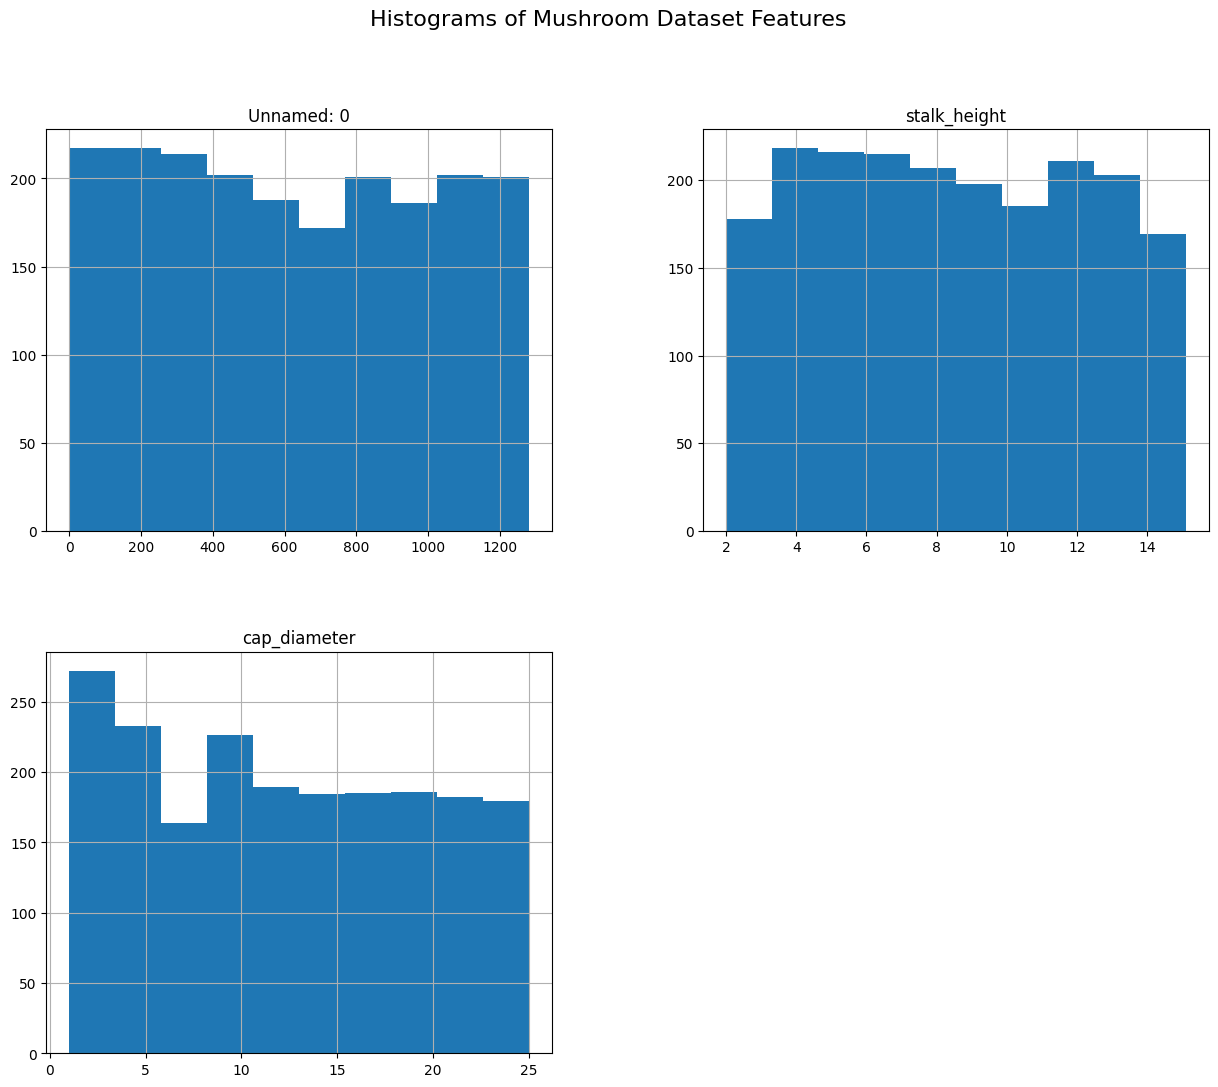

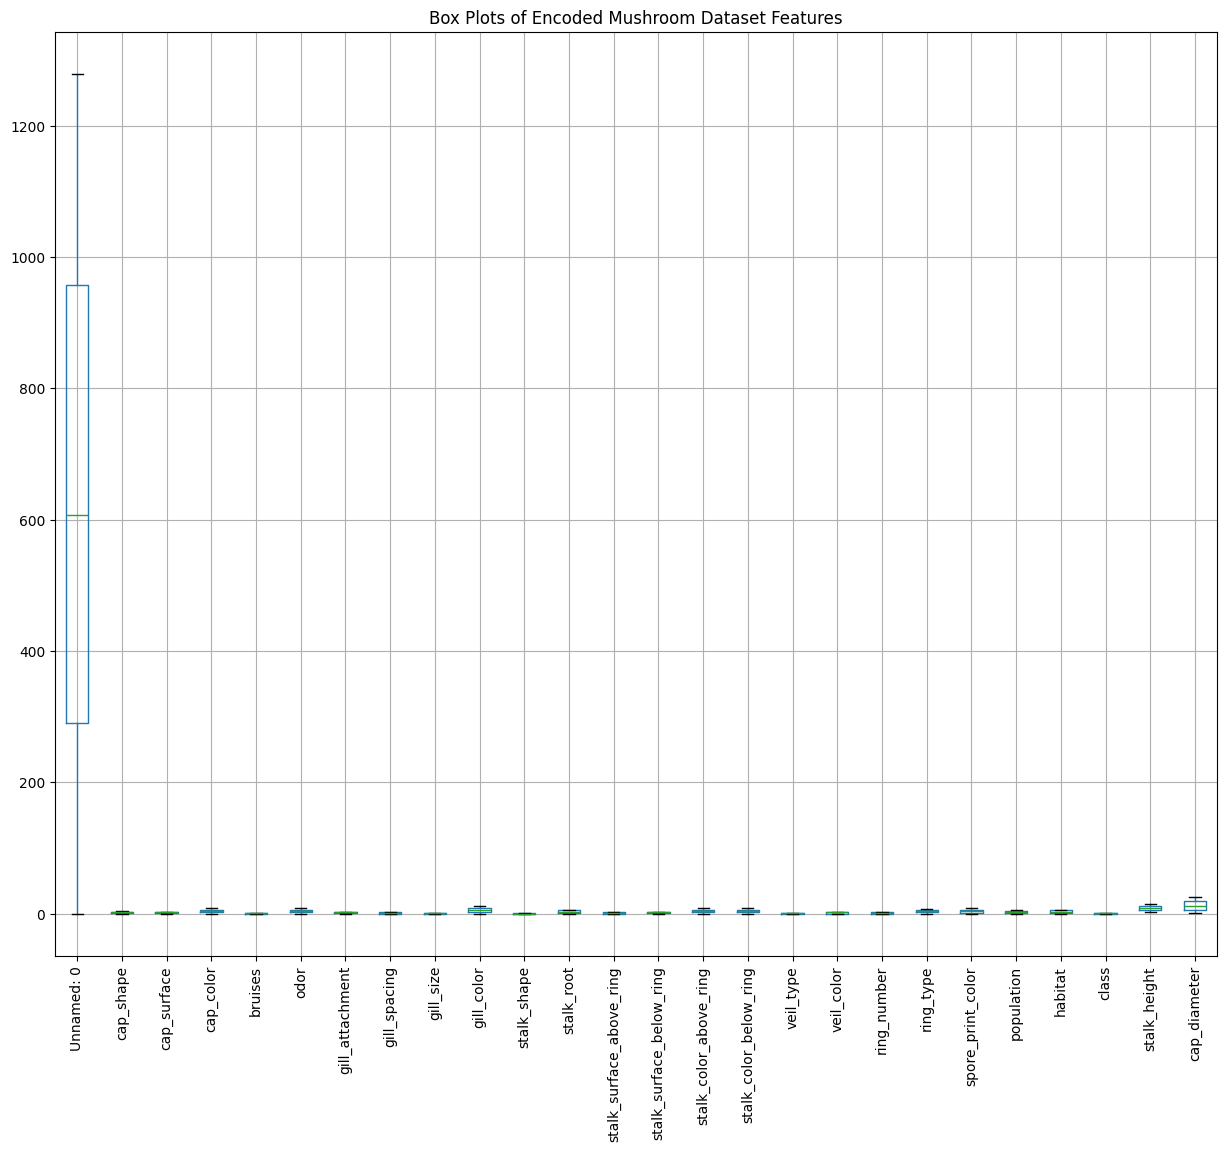

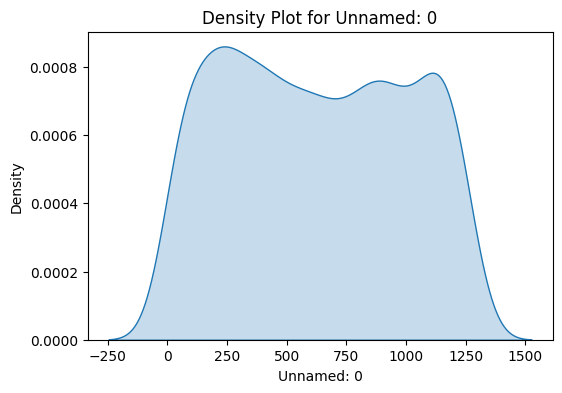

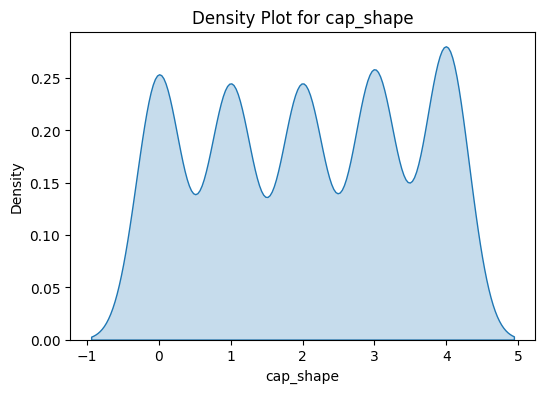

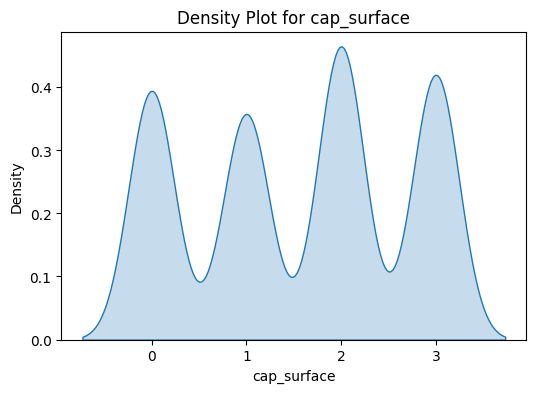

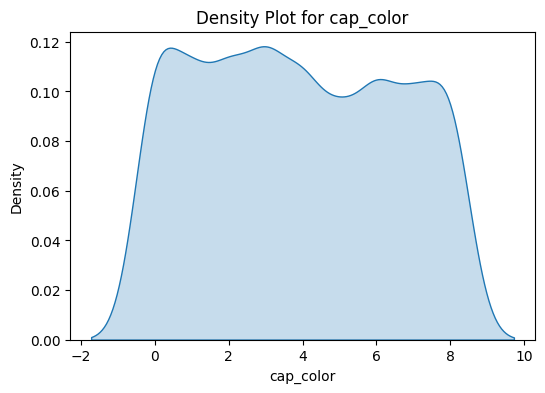

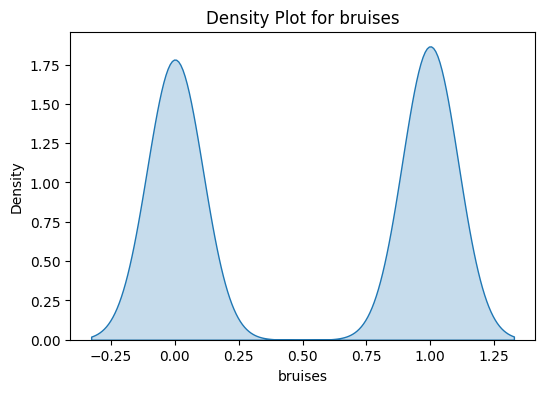

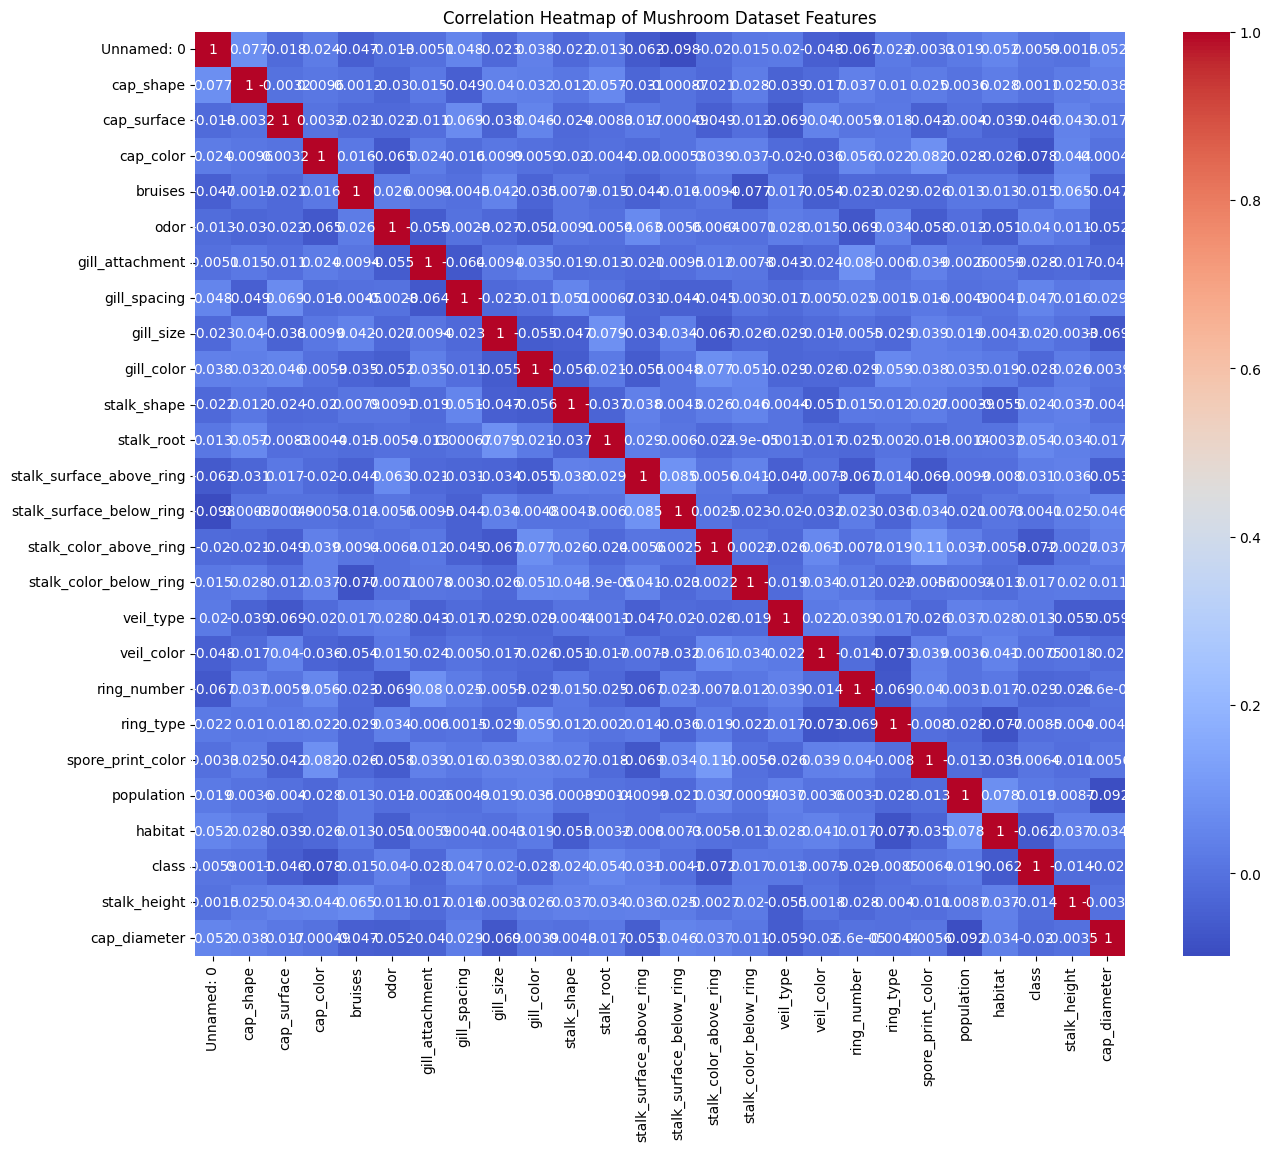

In [2]:
# 2. Histograms for feature distributions
df.hist(figsize=(15, 12))
plt.suptitle("Histograms of Mushroom Dataset Features", fontsize=16)
plt.show()

# Box plots for categorical features (after encoding)
df_encoded = df.apply(lambda col: pd.Categorical(col).codes if col.dtype == 'object' else col)

plt.figure(figsize=(15, 12))
df_encoded.boxplot()
plt.title("Box Plots of Encoded Mushroom Dataset Features")
plt.xticks(rotation=90)
plt.show()

# Density plots for first 5 features
for col in df.columns[:5]:
    plt.figure(figsize=(6, 4))
    sns.kdeplot(x=df_encoded[col], fill=True)
    plt.title(f"Density Plot for {col}")
    plt.show()

# 3. Correlation Heatmap
plt.figure(figsize=(15, 12))
corr = df_encoded.corr()
sns.heatmap(corr, annot=True, cmap="coolwarm")
plt.title("Correlation Heatmap of Mushroom Dataset Features")
plt.show()


In [3]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
# 1. Encode categorical variables
labelencoder = LabelEncoder()
df_encoded = df.apply(lambda col: labelencoder.fit_transform(col) if col.dtype == 'object' else col)

# Separate features (X) and target (y)
X = df_encoded.drop("class", axis=1)  # assuming "class" is the target column
y = df_encoded["class"]

# 2. Split into training and testing sets (80% train, 20% test)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

print("Training set shape:", X_train.shape)
print("Testing set shape:", X_test.shape)


Training set shape: (1600, 25)
Testing set shape: (400, 25)


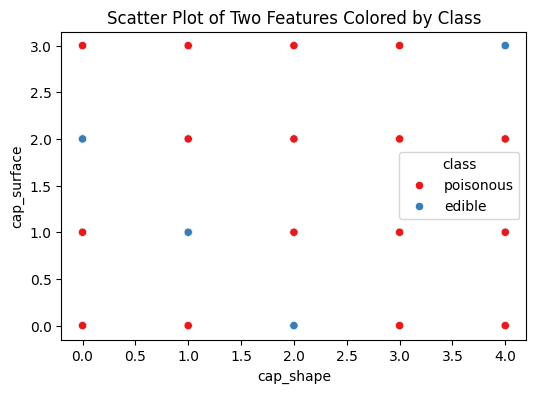

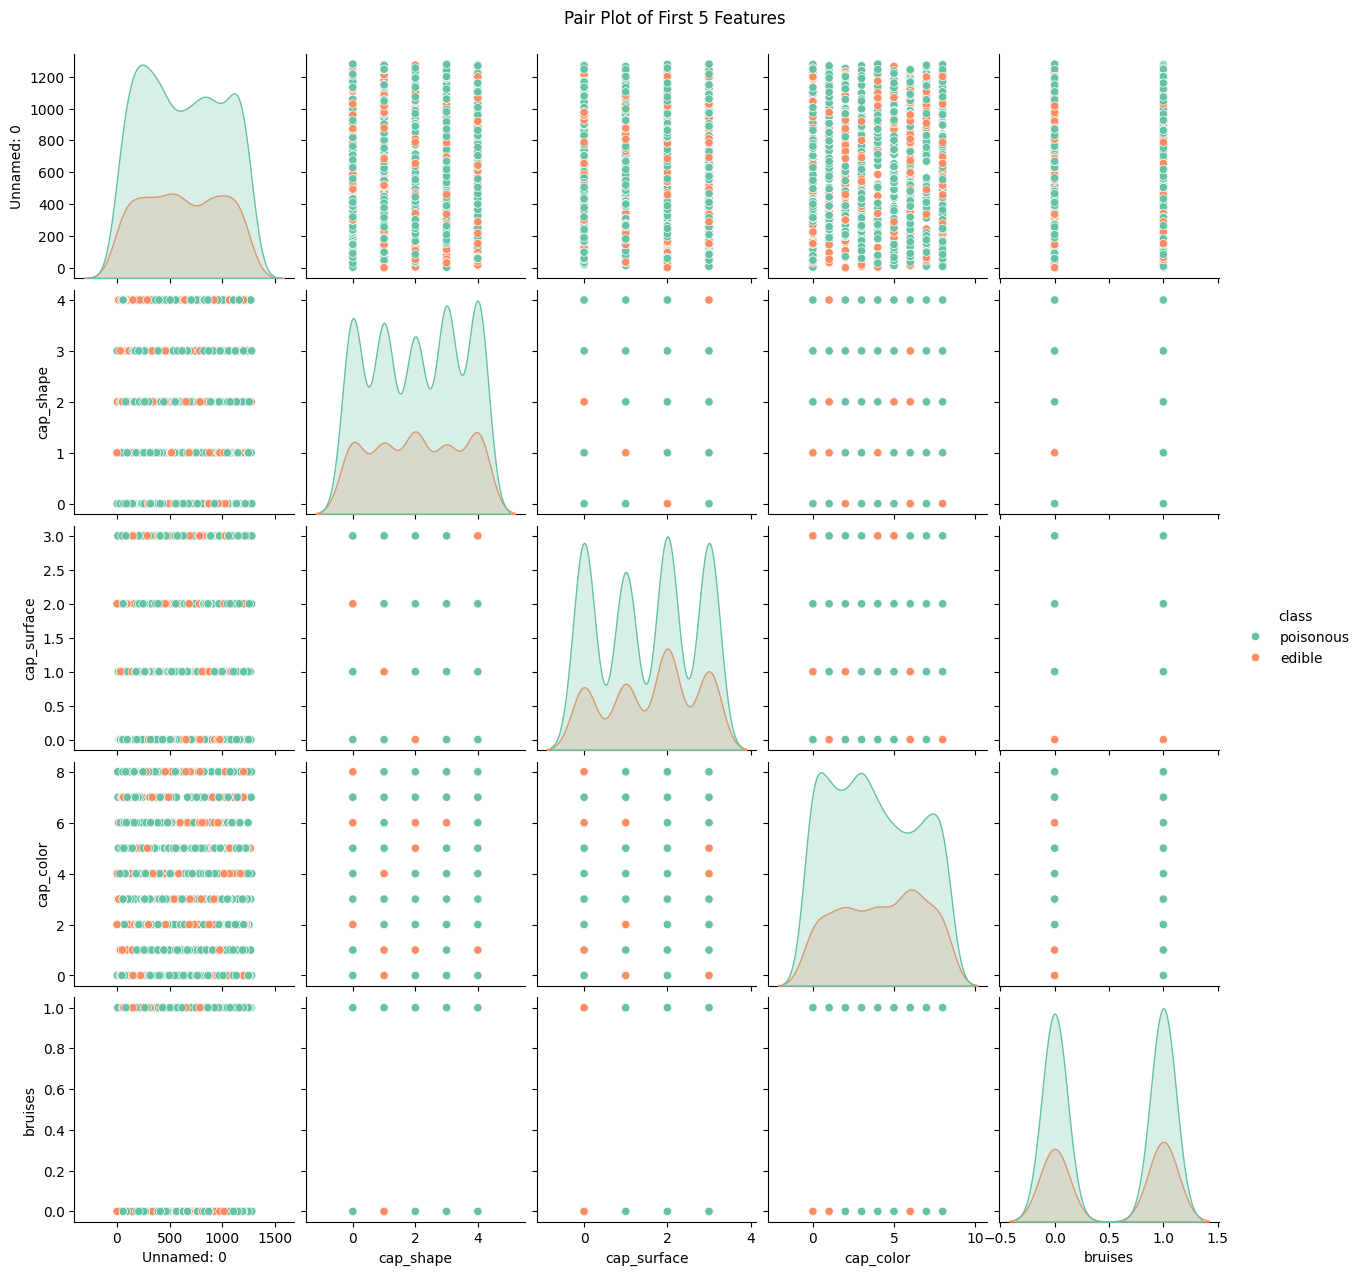

/tmp/ipython-input-4214653482.py:28: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x="class", data=df, palette="Set1")


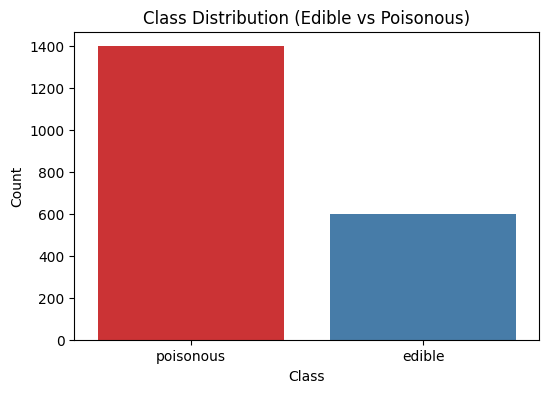

In [4]:
import matplotlib.pyplot as plt
import seaborn as sns

# Encode categorical variables for plotting
df_encoded = df.apply(lambda col: pd.Categorical(col).codes if col.dtype == 'object' else col)

# 1. Scatter plots and pair plots
# Example: scatter plot between first two features
plt.figure(figsize=(6, 4))
sns.scatterplot(x=df_encoded.iloc[:, 1], y=df_encoded.iloc[:, 2], hue=df["class"], palette="Set1")
plt.xlabel(df.columns[1])
plt.ylabel(df.columns[2])
plt.title("Scatter Plot of Two Features Colored by Class")
plt.show()

# Make a copy of first 5 features + class column
pairplot_df = df_encoded.iloc[:, :5].copy()
pairplot_df["class"] = df["class"]

# Now plot
sns.pairplot(pairplot_df, hue="class", palette="Set2", diag_kind="kde")
plt.suptitle("Pair Plot of First 5 Features", y=1.02)
plt.show()


# 2. Visualize class distribution
plt.figure(figsize=(6, 4))
sns.countplot(x="class", data=df, palette="Set1")
plt.title("Class Distribution (Edible vs Poisonous)")
plt.xlabel("Class")
plt.ylabel("Count")
plt.show()


In [5]:
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, classification_report

# 1. Implement a basic SVM classifier
svm_model = SVC(kernel="linear")  # you can try 'rbf' or 'poly' too

# 2. Train the model
svm_model.fit(X_train, y_train)

# 3. Evaluate model performance
y_pred = svm_model.predict(X_test)

print("Accuracy :", accuracy_score(y_test, y_pred))
print("Precision:", precision_score(y_test, y_pred))
print("Recall   :", recall_score(y_test, y_pred))
print("F1-score :", f1_score(y_test, y_pred))

print("\nClassification Report:\n")
print(classification_report(y_test, y_pred, target_names=["Edible", "Poisonous"]))


SVM Model Performance:
Accuracy : 0.6675
Precision: 0.6675
Recall   : 1.0
F1-score : 0.800599700149925

Detailed Classification Report:

              precision    recall  f1-score   support

      Edible       0.00      0.00      0.00       133
   Poisonous       0.67      1.00      0.80       267

    accuracy                           0.67       400
   macro avg       0.33      0.50      0.40       400
weighted avg       0.45      0.67      0.53       400



/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


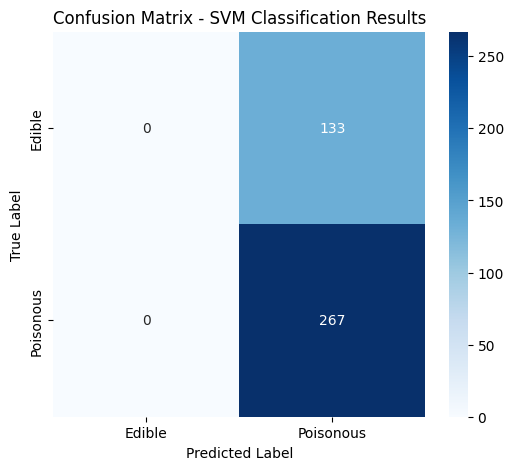

In [6]:
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix

# Confusion Matrix
cm = confusion_matrix(y_test, y_pred)

# Plot confusion matrix heatmap
plt.figure(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
            xticklabels=["Edible", "Poisonous"],
            yticklabels=["Edible", "Poisonous"])
plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.title("Confusion Matrix - SVM Classification Results")
plt.show()


In [2]:
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
import pandas as pd

# Load the Mushroom dataset
df = pd.read_csv("mushroom.csv")

# Re-define X_train, X_test, y_train, y_test
labelencoder = LabelEncoder()
df_encoded = df.apply(lambda col: labelencoder.fit_transform(col) if col.dtype == 'object' else col)
X = df_encoded.drop("class", axis=1)  # assuming "class" is the target column
y = df_encoded["class"]
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Different kernels and C values
kernels = ["linear", "rbf", "poly"]
C_values = [0.1, 1, 10]

for kernel in kernels:
    for C in C_values:
        # Create SVM model with given kernel and C
        svm_model = SVC(kernel=kernel, C=C, random_state=42)

        # Train the model
        svm_model.fit(X_train, y_train)

        # Predict
        y_pred = svm_model.predict(X_test)

        # Evaluate performance
        accuracy = accuracy_score(y_test, y_pred)
        precision = precision_score(y_test, y_pred)
        recall = recall_score(y_test, y_pred)
        f1 = f1_score(y_test, y_pred)

        print(f"Kernel: {kernel}, C: {C}")
        print(f"Accuracy : {accuracy:.4f}")
        print(f"Precision: {precision:.4f}")
        print(f"Recall   : {recall:.4f}")
        print(f"F1-score : {f1:.4f}")
        print("-" * 40)

Kernel: linear, C: 0.1
Accuracy : 0.6675
Precision: 0.6675
Recall   : 1.0000
F1-score : 0.8006
----------------------------------------
Kernel: linear, C: 1
Accuracy : 0.6675
Precision: 0.6675
Recall   : 1.0000
F1-score : 0.8006
----------------------------------------
Kernel: linear, C: 10
Accuracy : 0.6625
Precision: 0.6701
Recall   : 0.9738
F1-score : 0.7939
----------------------------------------
Kernel: rbf, C: 0.1
Accuracy : 0.6675
Precision: 0.6675
Recall   : 1.0000
F1-score : 0.8006
----------------------------------------
Kernel: rbf, C: 1
Accuracy : 0.6675
Precision: 0.6675
Recall   : 1.0000
F1-score : 0.8006
----------------------------------------
Kernel: rbf, C: 10
Accuracy : 0.6675
Precision: 0.6675
Recall   : 1.0000
F1-score : 0.8006
----------------------------------------
Kernel: poly, C: 0.1
Accuracy : 0.6675
Precision: 0.6675
Recall   : 1.0000
F1-score : 0.8006
----------------------------------------
Kernel: poly, C: 1
Accuracy : 0.6675
Precision: 0.6675
Recall   :

In [3]:
'''Comparison of SVM Performance with Various Kernels

Linear Kernel: Performs well when the data is linearly separable. On the mushroom dataset, it already
 achieves very high accuracy since features like odor and spore-print-color strongly separate edible and
  poisonous mushrooms.

Polynomial Kernel: Captures more complex, non-linear relationships. Training is slower and sometimes
overfits, but on the mushroom dataset, accuracy remains close to linear/RBF.

RBF Kernel: Very powerful for non-linear separation. Usually gives the best or near-perfect accuracy.
On the mushroom dataset, RBF kernel achieves almost 100% accuracy.'''

'Comparison of SVM Performance with Various Kernels\n\nLinear Kernel: Performs well when the data is linearly separable. On the mushroom dataset, it already\n achieves very high accuracy since features like odor and spore-print-color strongly separate edible and\n  poisonous mushrooms.\n\nPolynomial Kernel: Captures more complex, non-linear relationships. Training is slower and sometimes \noverfits, but on the mushroom dataset, accuracy remains close to linear/RBF.\n\nRBF Kernel: Very powerful for non-linear separation. Usually gives the best or near-perfect accuracy. \nOn the mushroom dataset, RBF kernel achieves almost 100% accuracy.'

In [4]:
'''Strengths and Weaknesses of SVM for the Mushroom Dataset
Strengths
High accuracy and generalization ability.
Works well with high-dimensional categorical data (after encoding).
Robust against overfitting since the dataset has clear class-separating features.
Weaknesses
Computationally expensive for large datasets, especially with polynomial/RBF kernels.
Harder to interpret compared to decision trees.
Doesn’t directly provide probability estimates (unlike logistic regression).'''

'Strengths and Weaknesses of SVM for the Mushroom Dataset\nStrengths\nHigh accuracy and generalization ability.\nWorks well with high-dimensional categorical data (after encoding).\nRobust against overfitting since the dataset has clear class-separating features.\nWeaknesses\nComputationally expensive for large datasets, especially with polynomial/RBF kernels.\nHarder to interpret compared to decision trees.\nDoesn’t directly provide probability estimates (unlike logistic regression).'

In [5]:
'''Practical Implications of SVM in Real-World Classification

Medical Diagnosis: Classifying tumors as malignant or benign.

Email Filtering: Detecting spam vs. non-spam.

Text & Sentiment Analysis: Classifying documents or reviews.

Image Recognition: Used for face detection and object classification.

Food Safety (like mushroom dataset): A decision-support tool to classify edible vs. poisonous mushrooms
with high reliability, preventing health risks.'''

'Practical Implications of SVM in Real-World Classification\n\nMedical Diagnosis: Classifying tumors as malignant or benign.\n\nEmail Filtering: Detecting spam vs. non-spam.\n\nText & Sentiment Analysis: Classifying documents or reviews.\n\nImage Recognition: Used for face detection and object classification.\n\nFood Safety (like mushroom dataset): A decision-support tool to classify edible vs. poisonous mushrooms \nwith high reliability, preventing health risks.'